# 1. Imports

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


from kaist_dataset.dataset import KAISTCalibrationDataset, KAISTRigCalibration, build_kaist_sequence_specs, make_kaist_dataloader

from obscalib.augmentations.config import AugmentationConfig, CalibrationEventConfig, FrameRandomizationConfig, NoiseAugmentationConfig, PerturbationMagnitudeConfig, PriorPerturbationConfig, SamplingRateAugmentationConfig, SE3NoiseConfig, VectorNoiseConfig
from obscalib.augmentations.pipeline import AugmentationPipeline
from obscalib.augmentations.profiles import TransitionProfile

from obscalib.calibration.update import CalibrationUpdater
from obscalib.config import CalibrationHeadConfig, MLPConfig, ObsCalibModelConfig, TransformerConfig, WindowingConfig
from obscalib.data.device import window_batch_to
from obscalib.data.structures import MeasurementType
from obscalib.geometry.lie import se3_log
from obscalib.geometry.processing import GeometryProcessor
from obscalib.models.obs_calib_model import ObsCalibModel
from obscalib.pipeline.window_step import WindowStep
from obscalib.tokenization.tokenizer import Tokenizer
from obscalib.training.checkpoint import load_training_checkpoint, read_training_checkpoint, save_training_checkpoint
from obscalib.training.metrics_logger import MetricsLogger

# 2. Experiment parameters

In [ ]:
##################################################
# Experiment
##################################################

# Name of this training run. Used to create the run directory and distinguish
# checkpoints / metric logs from other experiments.
RUN_NAME = "kaist_baseline_001"

# Global NumPy / PyTorch seed used for general reproducibility, including model
# parameter initialization unless a more specific generator is used.
RANDOM_SEED = 12345

# Seed used for stochastic augmentation of training minibatches.
# This generator keeps advancing, so training sees different augmentations.
TRAIN_AUGMENTATION_SEED = 23456

# Seed used for validation augmentation.
# We recreate the validation generator from this seed every epoch so validation
# sees the same synthetic calibration problems each time.
VALIDATION_AUGMENTATION_SEED = 34567

# Seed used for synthetic augmentation of the held-out test set.
TEST_AUGMENTATION_SEED = 45678


##################################################
# Device
##################################################

# Compute device used for model inference/training and GPU-compatible
# augmentations. Supported values here are "cpu", "cuda", or "auto".
DEVICE_NAME = "cuda"

if DEVICE_NAME == "auto":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    DEVICE = torch.device(DEVICE_NAME)

# Floating-point dtype used by the neural-network training path.
# float32 is the intended baseline for both CPU and GPU training.
MODEL_DTYPE = torch.float32


##################################################
# Dataset / windows
##################################################

# Duration [s] of one temporal observation window presented to the network.
# Each window contains all IMU and LiDAR measurements falling within this span.
WINDOW_DURATION_S = 5.0

# Temporal stride [s] between starts of consecutive dataset windows.
# With duration=10 s and stride=5 s, neighboring windows overlap by 5 s.
WINDOW_STRIDE_S = 5.0

# Safety limit on the number of samples of any individual sensor stream that
# may be included in one source window. Keep this high because sampling-rate
# reduction is performed later by augmentation rather than dataset truncation.
MAX_SAMPLES_PER_SENSOR = 700


##################################################
# DataLoader
##################################################

# Number of temporal windows processed simultaneously in one neural-network
# forward/backward pass.
BATCH_SIZE = 16

# Number of PyTorch DataLoader worker processes.
# Since the dataset is already materialized in RAM, 0 is a good initial choice.
NUM_WORKERS = 0

# If True, discard the final incomplete training minibatch when its number of
# windows is smaller than BATCH_SIZE. Validation and test should normally keep it.
DROP_LAST_TRAIN = True


##################################################
# Training
##################################################

# Number of complete passes through the training-window dataset.
NUM_EPOCHS = 50

# Initial learning rate of the AdamW optimizer for all trainable model parameters.
LEARNING_RATE = 3e-4

# AdamW decoupled L2-style weight-decay coefficient applied to trainable weights.
WEIGHT_DECAY = 1e-4

# Maximum global L2 norm of model gradients before optimizer.step().
# Gradients with a larger norm are rescaled to this value.
# Set to None if gradient clipping should be disabled.
GRADIENT_CLIP_NORM = 1.0

# Save/update the periodic "last" training checkpoint every this many epochs.
CHECKPOINT_EVERY_EPOCHS = 10

# Print an intermediate training-loss line every this many minibatches.
# Set to 0 to suppress per-batch progress output.
PRINT_EVERY_BATCHES = 200


##################################################
# Model
##################################################

# Common dimensionality of the canonical measurement part of each Transformer
# token. Gyroscope and accelerometer vectors use their first 3 entries and are
# zero-padded to 6; SE(3) logarithms already use all 6 [phi, rho] components.
MEASUREMENT_DIM = 6

# Complete input dimensionality of one measurement token before projection into
# the Transformer latent dimension:
#
# [canonical measurement (6) | corrected timestamp (1) | measurement type (1)]
#
# No observability features are included in the current baseline.
TOKEN_INPUT_DIM = MEASUREMENT_DIM + 2

# Hidden embedding dimension of the Transformer encoder.
# Every input token is projected from TOKEN_INPUT_DIM to D_MODEL before entering
# the self-attention layers, and every Transformer layer operates at this width.
D_MODEL = 128

# Number of attention heads in each multi-head self-attention block of the
# Transformer encoder.
#
# Each of the NUM_TRANSFORMER_LAYERS Transformer layers has N_HEADS attention
# heads. D_MODEL must be divisible by N_HEADS.
N_HEADS = 8

# Number of stacked Transformer encoder layers operating on the combined
# multi-sensor token sequence plus learned summary tokens.
NUM_TRANSFORMER_LAYERS = 12

# Width of the feed-forward subnetwork inside each Transformer encoder layer.
# This is the hidden dimension of the per-token FFN following self-attention,
# not the separate shared MLP used after the Transformer.
DIM_FEEDFORWARD = 512

# Number K of learned global summary tokens appended to the measurement
# sequence. After the Transformer, these K vectors are extracted and flattened
# into a K * D_MODEL feature vector for the shared MLP.
NUM_SUMMARY_TOKENS = 4

# Dropout probability used inside the Transformer encoder layers, including the
# attention / feed-forward Transformer blocks according to PyTorch's encoder.
TRANSFORMER_DROPOUT = 0.1

# Hidden-layer widths of the shared MLP applied after flattening the learned
# Transformer summary tokens. This MLP is shared by all calibration heads.
MLP_HIDDEN_DIMS = (256, 128)

# Output dimensionality of the shared MLP.
# This shared feature vector is passed to every sensor-specific calibration head.
SHARED_FEATURE_DIM = 128

# Hidden-layer widths of each calibration-specific output head.
# There is one head for each calibration key, currently e.g. "imu" and "lidar".
HEAD_HIDDEN_DIMS = (128, 64)

# Number of values describing the current calibration state supplied to each
# calibration head:
#
# [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z, tau]
#
# where [phi, rho] = Log(T_current) and tau is the current temporal offset.
CALIBRATION_CONTEXT_DIM = 7


##################################################
# Loss normalization - from STDs
##################################################

# Characteristic rotation-error scale [rad] used to normalize rotational
# components of delta_xi before applying Smooth L1 loss.
# An angular correction error near 15 degrees therefore has normalized scale ~1.
ROTATION_LOSS_SCALE_RAD = np.deg2rad(5.0)

# Characteristic translational SE(3)-tangent error scale [m].
# This normalizes the rho components of delta_xi before Smooth L1 loss.
TRANSLATION_LOSS_SCALE_M = 0.05

# Characteristic temporal-calibration error scale [s].
# A delta_tau prediction error near 30 ms has normalized scale ~1.
TIME_OFFSET_LOSS_SCALE_S = 0.015

# Characteristic scale [s] for the auxiliary predicted calibration-event time.
# Using the full window duration expresses change-time error relative to window size.
CHANGE_TIME_LOSS_SCALE_S = WINDOW_DURATION_S

# Relative contribution of the normalized rotational correction loss to the
# total calibration-head loss.
ROTATION_LOSS_WEIGHT = 2.0

# Relative contribution of the normalized translational correction loss.
TRANSLATION_LOSS_WEIGHT = 1.0

# Relative contribution of the normalized temporal-offset correction loss.
TIME_OFFSET_LOSS_WEIGHT = 1.0

# Relative contribution of the auxiliary binary change-event classification
# loss. This does not gate delta_xi or delta_tau.
CHANGE_EVENT_LOSS_WEIGHT = 0.1

# Relative contribution of the auxiliary calibration change-time regression
# loss. It is evaluated only for samples in which a true event occurred.
CHANGE_TIME_LOSS_WEIGHT = 0.1


##################################################
# Learning-rate scheduler
##################################################

# Multiplicative factor applied to the optimizer learning rate when validation
# loss stops improving according to ReduceLROnPlateau.
# For example, 3e-4 becomes 1.5e-4 when this factor is 0.5.
LR_REDUCTION_FACTOR = 0.5

# Number of validation epochs without sufficient improvement before
# ReduceLROnPlateau decreases the learning rate.
LR_PATIENCE_EPOCHS = 5


##################################################
# Checkpoint resume
##################################################

# Path to a previously saved restartable training checkpoint.
# Leave as None to start a fresh model/optimizer state.
RESUME_CHECKPOINT = None

# Example:
# RESUME_CHECKPOINT = ROOT / "runs" / RUN_NAME / "last.pt"


##################################################
# Reproducibility initialization
##################################################

# Seed PyTorch's default RNG, used among other things for model initialization.
torch.manual_seed(RANDOM_SEED)

# Seed NumPy's default RNG for any NumPy-side random operations.
np.random.seed(RANDOM_SEED)


print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)

Device: cuda
Batch size: 16


# 3. Dataset paths and train/validation/test split

In [3]:
KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")


##################################################
# Sequence-level split
##################################################

TRAIN_NAMES = [
    # Six sequences
    "Urban08",
    "Urban12",
    "Urban13",
    "Urban14",
    "Urban15",
    "Urban16",
]

VAL_NAMES = [
    # Two sequences
    "Urban26",
    "Urban28",
]

TEST_NAMES = [
    # Two sequences
    "Urban38",
    "Urban39",
]


ALL_SEQUENCE_NAMES = TRAIN_NAMES + VAL_NAMES + TEST_NAMES

if len(ALL_SEQUENCE_NAMES) != len(set(ALL_SEQUENCE_NAMES)):
    raise ValueError("Train, validation, and test sequence sets overlap.")

print("train:", TRAIN_NAMES)
print("validation:", VAL_NAMES)
print("test:", TEST_NAMES)

train: ['Urban08', 'Urban12', 'Urban13', 'Urban14', 'Urban15', 'Urban16']
validation: ['Urban26', 'Urban28']
test: ['Urban38', 'Urban39']


# 4. KAIST calibration and windowing

In [4]:
##################################################
# KAIST body-frame calibration
##################################################

T_B_L = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933, 0.707457,  1.90953],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_I_B = np.array([
    [1.0, 0.0, 0.0, -0.07],
    [0.0, 1.0, 0.0,  0.0],
    [0.0, 0.0, 1.0,  1.7],
    [0.0, 0.0, 0.0,  1.0],
], dtype=float)

T_B_I = np.linalg.inv(T_I_B)


rig_calibration = KAISTRigCalibration(
    T_B_I=T_B_I,
    T_B_L=T_B_L,
    tau_imu_s=0.0,
    tau_lidar_s=0.0,
)


windowing_config = WindowingConfig(
    window_duration_s=WINDOW_DURATION_S,
    window_stride_s=WINDOW_STRIDE_S,
    max_samples_per_sensor=MAX_SAMPLES_PER_SENSOR,
)

# 5. Load all datasets into RAM

In [5]:
all_specs = build_kaist_sequence_specs(
    sequence_names=ALL_SEQUENCE_NAMES,
    kaist_dataset_root=KAIST_DATASET_ROOT,
    lidar_pose_root=LIDAR_POSE_ROOT,
)

spec_by_name = {
    spec.name: spec
    for spec in all_specs
}


train_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in TRAIN_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)

val_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in VAL_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)

test_dataset = KAISTCalibrationDataset(
    [spec_by_name[name] for name in TEST_NAMES],
    rig_calibration,
    windowing_config,
    measurement_dtype=torch.float32,
    source_timestamp_dtype=torch.float64,
    window_timestamp_dtype=torch.float32,
)


print(train_dataset.summary())
print()
print(val_dataset.summary())
print()
print(test_dataset.summary())

KAISTCalibrationDataset: 2021 windows from 6 sequences
approximate tensor storage: 37.6 MiB
  Urban08: windows=59, duration=297.8s, IMU=30800, LiDAR=2952
  Urban12: windows=475, duration=2478.6s, IMU=249198, LiDAR=23222
  Urban13: windows=227, duration=1446.5s, IMU=145492, LiDAR=10536
  Urban14: windows=288, duration=1737.0s, IMU=174681, LiDAR=13638
  Urban15: windows=184, duration=1034.3s, IMU=104795, LiDAR=9011
  Urban16: windows=788, duration=4458.2s, IMU=449215, LiDAR=37703

KAISTCalibrationDataset: 422 windows from 2 sequences
approximate tensor storage: 7.9 MiB
  Urban26: windows=95, duration=567.0s, IMU=58371, LiDAR=4553
  Urban28: windows=327, duration=1958.6s, IMU=197456, LiDAR=15651

KAISTCalibrationDataset: 705 windows from 2 sequences
approximate tensor storage: 13.2 MiB
  Urban38: windows=354, duration=2147.3s, IMU=216225, LiDAR=17005
  Urban39: windows=351, duration=1856.3s, IMU=186682, LiDAR=17195


# 6. DataLoaders

In [6]:
train_shuffle_generator = torch.Generator().manual_seed(RANDOM_SEED)


train_loader = make_kaist_dataloader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    num_workers=NUM_WORKERS,
    generator=train_shuffle_generator,
)

val_loader = make_kaist_dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)

test_loader = make_kaist_dataloader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)


print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 126
validation batches: 27
test batches: 45


# 7. Training augmentation configuration

In [7]:
augmentation_config = AugmentationConfig(
    sampling_rate=SamplingRateAugmentationConfig(
        enabled=True,
        minimum_imu_frequency_hz=40.0,
        minimum_lidar_frequency_hz=5.0,
        imu_probability=0.8,
        lidar_probability=0.5,
    ),

    frame_randomization=FrameRandomizationConfig(
        enabled=True,
    ),

    prior_perturbation=PriorPerturbationConfig(
        enabled=True,
        probability=0.8,
        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(15.0),
        ),
        translation=PerturbationMagnitudeConfig(
            maximum=0.15,
        ),
        time_offset=PerturbationMagnitudeConfig(
            maximum=0.03,
        ),
    ),

    calibration_event=CalibrationEventConfig(
        enabled=True,
        event_probability=0.5,

        rotation_probability=0.8,
        translation_probability=0.7,
        time_offset_probability=0.5,

        rotation=PerturbationMagnitudeConfig(
            maximum=np.deg2rad(10.0),
        ),
        translation=PerturbationMagnitudeConfig(
            maximum=0.10,
        ),
        time_offset=PerturbationMagnitudeConfig(
            maximum=0.02,
        ),

        profile_weights={
            TransitionProfile.STEP: 1.0,
            TransitionProfile.LINEAR: 1.0,
            TransitionProfile.SMOOTHSTEP: 1.0,
        },

        minimum_transition_duration_s=0.5,
        maximum_transition_duration_s=3.0,

        minimum_pre_event_fraction=0.2,
        minimum_post_event_fraction=0.2,
    ),

    noise=NoiseAugmentationConfig(
        enabled=True,

        vector_by_type={
            MeasurementType.IMU_GYROSCOPE: VectorNoiseConfig(
                gaussian_std=0.01,
                window_bias_std=0.003,
            ),
            MeasurementType.IMU_ACCELEROMETER: VectorNoiseConfig(
                gaussian_std=0.08,
                window_bias_std=0.03,
            ),
        },

        se3_by_type={
            MeasurementType.LIDAR_POSE: SE3NoiseConfig(
                rotation_std=np.deg2rad(0.15),
                translation_std=0.01,
            ),
        },
    ),
)


augmentation_pipeline = AugmentationPipeline(
    augmentation_config
)

# 8. Build the model and complete window pipeline

In [8]:
model_config = ObsCalibModelConfig(
    transformer=TransformerConfig(
        input_dim=TOKEN_INPUT_DIM,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_TRANSFORMER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=TRANSFORMER_DROPOUT,
        activation="gelu",
        num_summary_tokens=NUM_SUMMARY_TOKENS,
    ),

    mlp=MLPConfig(
        hidden_dims=MLP_HIDDEN_DIMS,
        output_dim=SHARED_FEATURE_DIM,
        activation="gelu",
        dropout=0.1,
    ),

    calibration_head=CalibrationHeadConfig(
        calibration_context_dim=CALIBRATION_CONTEXT_DIM,
        hidden_dims=HEAD_HIDDEN_DIMS,
        activation="gelu",
        dropout=0.1,
    ),

    head_keys=(
        "imu",
        "lidar",
    ),
)


model = ObsCalibModel(
    model_config
).to(
    device=DEVICE,
    dtype=MODEL_DTYPE,
)


geometry_processor = GeometryProcessor()

tokenizer = Tokenizer(
    measurement_dim=MEASUREMENT_DIM,
)

calibration_updater = CalibrationUpdater()


window_step = WindowStep(
    geometry_processor=geometry_processor,
    tokenizer=tokenizer,
    model=model,
    calibration_updater=calibration_updater,
    observability_estimator=None,
    observability_mapper=None,
)


num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

num_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Parameters:", num_parameters)
print("Trainable parameters:", num_trainable_parameters)

Parameters: 2614162
Trainable parameters: 2614162


In [9]:
##################################################
# Experiment snapshot stored inside checkpoints
##################################################

EXPERIMENT_SNAPSHOT = {
    "schema_version": 1,

    # Exact model architecture required to reconstruct ObsCalibModel.
    "model_config": model_config,

    # Tokenizer configuration not contained in ObsCalibModelConfig.
    "measurement_dim": MEASUREMENT_DIM,

    # Dataset window construction used during training.
    "windowing_config": windowing_config,

    # Nominal KAIST sensor-to-body calibration used to construct the dataset.
    "rig_calibration": rig_calibration,

    # Synthetic training distribution. Rollout evaluation does not have to
    # apply it, but saving it documents exactly what the network saw.
    "augmentation_config": augmentation_config,

    # Training loss definition. Not required for inference, but important for
    # reproducing and interpreting the checkpoint.
    "loss_config": {
        "rotation_loss_scale_rad": ROTATION_LOSS_SCALE_RAD,
        "translation_loss_scale_m": TRANSLATION_LOSS_SCALE_M,
        "time_offset_loss_scale_s": TIME_OFFSET_LOSS_SCALE_S,
        "change_time_loss_scale_s": CHANGE_TIME_LOSS_SCALE_S,
        "rotation_loss_weight": ROTATION_LOSS_WEIGHT,
        "translation_loss_weight": TRANSLATION_LOSS_WEIGHT,
        "time_offset_loss_weight": TIME_OFFSET_LOSS_WEIGHT,
        "change_event_loss_weight": CHANGE_EVENT_LOSS_WEIGHT,
        "change_time_loss_weight": CHANGE_TIME_LOSS_WEIGHT,
    },

    # Dataset split used by this trained model.
    "sequence_split": {
        "train": tuple(TRAIN_NAMES),
        "validation": tuple(VAL_NAMES),
        "test": tuple(TEST_NAMES),
    },

    # Useful provenance, but not needed to execute the model.
    "training_config": {
        "run_name": RUN_NAME,
        "model_dtype": str(MODEL_DTYPE),
        "random_seed": RANDOM_SEED,
        "train_augmentation_seed": TRAIN_AUGMENTATION_SEED,
        "validation_augmentation_seed": VALIDATION_AUGMENTATION_SEED,
        "test_augmentation_seed": TEST_AUGMENTATION_SEED,
    },
}

# 9. Optimizer and scheduler

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_REDUCTION_FACTOR,
    patience=LR_PATIENCE_EPOCHS,
)

# 10. Loss function

In [11]:
def compute_training_loss(window, model_output):
    """Compute normalized calibration and auxiliary losses for all model heads."""

    if window.targets is None:
        raise ValueError("Training window has no targets.")

    total_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)

    metrics = {}
    num_heads = 0

    for calibration_key, prediction in model_output.predictions.items():
        if calibration_key not in window.targets:
            raise KeyError(f"Missing training target for calibration head {calibration_key!r}.")

        target = window.targets[calibration_key]
        current_state = window.current_calibration[calibration_key]

        if target.next_transform is None or target.next_time_offset is None:
            raise ValueError(f"Calibration target {calibration_key!r} does not contain final calibration state.")

        ##################################################
        # Geometric correction target
        ##################################################

        target_delta_transform = target.next_transform @ torch.linalg.inv(current_state.transform)
        target_delta_xi = se3_log(target_delta_transform)

        target_delta_tau = target.next_time_offset - current_state.time_offset

        ##################################################
        # Primary calibration losses
        ##################################################

        rotation_loss = F.smooth_l1_loss(
            prediction.delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD,
            target_delta_xi[:, :3] / ROTATION_LOSS_SCALE_RAD,
        )

        translation_loss = F.smooth_l1_loss(
            prediction.delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M,
            target_delta_xi[:, 3:] / TRANSLATION_LOSS_SCALE_M,
        )

        time_offset_loss = F.smooth_l1_loss(
            prediction.delta_tau / TIME_OFFSET_LOSS_SCALE_S,
            target_delta_tau / TIME_OFFSET_LOSS_SCALE_S,
        )

        ##################################################
        # Auxiliary event losses
        ##################################################

        if target.change_label is None:
            change_event_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)
            change_time_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)
            change_labels = None
        else:
            change_labels = target.change_label.to(dtype=prediction.change_event_logit.dtype)

            change_event_loss = F.binary_cross_entropy_with_logits(
                prediction.change_event_logit,
                change_labels,
            )

            positive_event_mask = change_labels[:, 0] > 0.5

            if target.change_time is not None and torch.any(positive_event_mask):
                change_time_loss = F.smooth_l1_loss(
                    prediction.change_time[positive_event_mask] / CHANGE_TIME_LOSS_SCALE_S,
                    target.change_time[positive_event_mask] / CHANGE_TIME_LOSS_SCALE_S,
                )
            else:
                change_time_loss = torch.zeros((), dtype=MODEL_DTYPE, device=DEVICE)

        ##################################################
        # Head loss
        ##################################################

        head_loss = (
            ROTATION_LOSS_WEIGHT * rotation_loss
            + TRANSLATION_LOSS_WEIGHT * translation_loss
            + TIME_OFFSET_LOSS_WEIGHT * time_offset_loss
            + CHANGE_EVENT_LOSS_WEIGHT * change_event_loss
            + CHANGE_TIME_LOSS_WEIGHT * change_time_loss
        )

        total_loss = total_loss + head_loss
        num_heads += 1

        ##################################################
        # Human-readable metrics
        ##################################################

        rotation_error_rad = torch.linalg.vector_norm(
            prediction.delta_xi[:, :3] - target_delta_xi[:, :3],
            dim=-1,
        )

        translation_error_m = torch.linalg.vector_norm(
            prediction.delta_xi[:, 3:] - target_delta_xi[:, 3:],
            dim=-1,
        )

        time_offset_error_s = torch.abs(
            prediction.delta_tau[:, 0] - target_delta_tau[:, 0]
        )

        metrics[f"{calibration_key}/rotation_error_deg"] = torch.rad2deg(rotation_error_rad).mean().detach().item()
        metrics[f"{calibration_key}/translation_error_cm"] = (translation_error_m * 100.0).mean().detach().item()
        metrics[f"{calibration_key}/time_offset_error_ms"] = (time_offset_error_s * 1000.0).mean().detach().item()

        metrics[f"{calibration_key}/loss_rotation"] = rotation_loss.detach().item()
        metrics[f"{calibration_key}/loss_translation"] = translation_loss.detach().item()
        metrics[f"{calibration_key}/loss_time_offset"] = time_offset_loss.detach().item()
        metrics[f"{calibration_key}/loss_change_event"] = change_event_loss.detach().item()
        metrics[f"{calibration_key}/loss_change_time"] = change_time_loss.detach().item()

        if change_labels is not None:
            predicted_labels = torch.sigmoid(prediction.change_event_logit[:, 0]) >= 0.5
            true_labels = change_labels[:, 0] >= 0.5

            metrics[f"{calibration_key}/event_accuracy"] = (predicted_labels == true_labels).float().mean().detach().item()

            if target.change_time is not None and torch.any(true_labels):
                metrics[f"{calibration_key}/change_time_error_s"] = torch.abs(prediction.change_time[true_labels, 0] - target.change_time[true_labels, 0]).mean().detach().item()

    if num_heads == 0:
        raise ValueError("Model produced no calibration predictions.")

    total_loss = total_loss / num_heads

    metrics["loss_total"] = total_loss.detach().item()

    return total_loss, metrics

# 11. Generator helper and metric averaging

In [12]:
def make_augmentation_generator(seed: int):
    """Create a generator on the same device used by augmentation tensors."""

    return torch.Generator(device=DEVICE.type).manual_seed(seed)


def accumulate_metrics(metric_sums: dict[str, float], metrics: dict[str, float], batch_size: int):
    for key, value in metrics.items():
        metric_sums[key] = metric_sums.get(key, 0.0) + float(value) * batch_size


def normalize_metrics(metric_sums: dict[str, float], num_samples: int):
    return {
        key: value / num_samples
        for key, value in metric_sums.items()
    }

# 12. One training/evaluation epoch

In [13]:
def run_epoch(loader, *, training: bool, augmentation_generator: torch.Generator, global_step: int = 0):
    """Run one training or evaluation epoch."""

    if training:
        model.train()
    else:
        model.eval()

    metric_sums = {}
    num_samples = 0

    start_time = time.perf_counter()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    grad_context = torch.enable_grad() if training else torch.no_grad()

    with grad_context:
        for batch_index, base_window in enumerate(loader):
            ##################################################
            # CPU RAM -> selected compute device
            ##################################################

            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            ##################################################
            # Synthetic calibration problem
            ##################################################

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            training_window = augmentation_result.augmented_window

            ##################################################
            # Forward
            ##################################################

            if training:
                optimizer.zero_grad(set_to_none=True)

            step_result = window_step(
                training_window
            )

            loss, metrics = compute_training_loss(
                training_window,
                step_result.model_output,
            )

            ##################################################
            # Backward
            ##################################################

            if training:
                loss.backward()

                if GRADIENT_CLIP_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRADIENT_CLIP_NORM,
                    )

                optimizer.step()

                global_step += 1

            ##################################################
            # Epoch metric accumulation
            ##################################################

            batch_size = next(iter(training_window.streams.values())).values.shape[0]

            accumulate_metrics(
                metric_sums,
                metrics,
                batch_size,
            )

            num_samples += batch_size

            if training and PRINT_EVERY_BATCHES > 0 and (batch_index + 1) % PRINT_EVERY_BATCHES == 0:
                print(
                    f"batch {batch_index + 1:5d}/{len(loader):5d}  "
                    f"loss={metrics['loss_total']:.5f}"
                )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed_s = time.perf_counter() - start_time

    epoch_metrics = normalize_metrics(
        metric_sums,
        num_samples,
    )

    epoch_metrics["epoch_time_s"] = elapsed_s
    epoch_metrics["samples_per_s"] = num_samples / elapsed_s

    return epoch_metrics, global_step

# 13. One-batch sanity test before training

In [14]:
train_augmentation_generator = make_augmentation_generator(
    TRAIN_AUGMENTATION_SEED
)

base_window = next(iter(train_loader))

base_window = window_batch_to(
    base_window,
    DEVICE,
    dtype=MODEL_DTYPE,
)

augmentation_result = augmentation_pipeline(
    base_window,
    generator=train_augmentation_generator,
)

sanity_window = augmentation_result.augmented_window

with torch.no_grad():
    sanity_result = window_step(
        sanity_window
    )

sanity_loss, sanity_metrics = compute_training_loss(
    sanity_window,
    sanity_result.model_output,
)

print("Sanity loss:", sanity_loss.item())

for key, value in sanity_metrics.items():
    print(f"{key}: {value}")

Sanity loss: 6.086313247680664
imu/rotation_error_deg: 10.978057861328125
imu/translation_error_cm: 10.715206146240234
imu/time_offset_error_ms: 26.50147247314453
imu/loss_rotation: 0.7042355537414551
imu/loss_translation: 0.6359552145004272
imu/loss_time_offset: 1.3123159408569336
imu/loss_change_event: 0.7032660245895386
imu/loss_change_time: 0.12963330745697021
imu/event_accuracy: 0.4375
imu/change_time_error_s: 2.491237163543701
lidar/rotation_error_deg: 11.690728187561035
lidar/translation_error_cm: 20.82646942138672
lidar/time_offset_error_ms: 88.695068359375
lidar/loss_rotation: 0.7629196643829346
lidar/loss_translation: 1.7091808319091797
lidar/loss_time_offset: 5.4130048751831055
lidar/loss_change_event: 0.68950355052948
lidar/loss_change_time: 0.15617969632148743
lidar/event_accuracy: 0.6875
lidar/change_time_error_s: 2.729992389678955
loss_total: 6.086313247680664


In [15]:
for calibration_key, prediction in sanity_result.model_output.predictions.items():
    print()
    print(calibration_key)
    print("change_event_logit:", prediction.change_event_logit.shape)
    print("change_time:", prediction.change_time.shape)
    print("delta_xi:", prediction.delta_xi.shape)
    print("delta_tau:", prediction.delta_tau.shape)


imu
change_event_logit: torch.Size([16, 1])
change_time: torch.Size([16, 1])
delta_xi: torch.Size([16, 6])
delta_tau: torch.Size([16, 1])

lidar
change_event_logit: torch.Size([16, 1])
change_time: torch.Size([16, 1])
delta_xi: torch.Size([16, 6])
delta_tau: torch.Size([16, 1])


# 14. Run directory, logger, and optional resume

In [16]:
RUN_DIR = ROOT / "runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = RUN_DIR / "metrics.jsonl"
LAST_CHECKPOINT_PATH = RUN_DIR / "last.pt"
BEST_CHECKPOINT_PATH = RUN_DIR / "best.pt"


train_augmentation_generator = make_augmentation_generator(
    TRAIN_AUGMENTATION_SEED
)


start_epoch = 0
global_step = 0
best_validation_loss = float("inf")


if RESUME_CHECKPOINT is not None:
    checkpoint = load_training_checkpoint(
        RESUME_CHECKPOINT,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        generators={
            "train_augmentation": train_augmentation_generator,
            "train_shuffle": train_shuffle_generator,
        },
        map_location=DEVICE,
    )

    start_epoch = int(checkpoint.get("epoch", 0))
    global_step = int(checkpoint.get("global_step", 0))
    best_validation_loss = float(checkpoint.get("extra_state", {}).get("best_validation_loss", float("inf")))

    print("Resumed from:", RESUME_CHECKPOINT)
    print("start epoch:", start_epoch)
    print("global step:", global_step)

Resumed from: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/runs/kaist_baseline_001/last.pt
start epoch: 30
global step: 3780


# 15. Main training loop

In [17]:
torch.cuda.empty_cache()

In [18]:
history = []


with MetricsLogger(
    METRICS_PATH,
    append=RESUME_CHECKPOINT is not None,
) as logger:

    if RESUME_CHECKPOINT is None:
        logger.log_config(
            model_config,
            name="model_config",
        )

        logger.log_config(
            augmentation_config,
            name="augmentation_config",
        )

        logger.log_config(
            {
                "device": str(DEVICE),
                "batch_size": BATCH_SIZE,
                "window_duration_s": WINDOW_DURATION_S,
                "window_stride_s": WINDOW_STRIDE_S,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "train_sequences": TRAIN_NAMES,
                "validation_sequences": VAL_NAMES,
                "test_sequences": TEST_NAMES,
            },
            name="experiment",
        )

    for epoch in range(start_epoch, NUM_EPOCHS):
        print()
        print("=" * 80)
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
        print("=" * 80)

        ##################################################
        # Train
        ##################################################

        train_metrics, global_step = run_epoch(
            train_loader,
            training=True,
            augmentation_generator=train_augmentation_generator,
            global_step=global_step,
        )

        ##################################################
        # Validation
        ##################################################

        validation_augmentation_generator = make_augmentation_generator(
            VALIDATION_AUGMENTATION_SEED
        )

        val_metrics, _ = run_epoch(
            val_loader,
            training=False,
            augmentation_generator=validation_augmentation_generator,
            global_step=global_step,
        )

        ##################################################
        # Scheduler
        ##################################################

        scheduler.step(
            val_metrics["loss_total"]
        )

        current_learning_rate = optimizer.param_groups[0]["lr"]

        ##################################################
        # Console + log
        ##################################################

        print(
            f"train loss={train_metrics['loss_total']:.6f}  "
            f"val loss={val_metrics['loss_total']:.6f}  "
            f"lr={current_learning_rate:.3e}"
        )

        # print(
        #     f"train throughput={train_metrics['samples_per_s']:.1f} windows/s  "
        #     f"val throughput={val_metrics['samples_per_s']:.1f} windows/s"
        # )

        logger.log_metrics(
            {
                **train_metrics,
                "learning_rate": current_learning_rate,
            },
            split="train",
            epoch=epoch + 1,
            step=global_step,
        )

        logger.log_metrics(
            val_metrics,
            split="validation",
            epoch=epoch + 1,
            step=global_step,
        )

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_metrics["loss_total"],
                "val_loss": val_metrics["loss_total"],
                "learning_rate": current_learning_rate,
            }
        )

        ##################################################
        # Best checkpoint
        ##################################################

        if val_metrics["loss_total"] < best_validation_loss:
            best_validation_loss = val_metrics["loss_total"]

            save_training_checkpoint(
                BEST_CHECKPOINT_PATH,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch + 1,
                global_step=global_step,
                metrics=val_metrics,
                generators={
                    "train_augmentation": train_augmentation_generator,
                    "train_shuffle": train_shuffle_generator,
                },
                extra_state={
                    "best_validation_loss": best_validation_loss,
                    "experiment": EXPERIMENT_SNAPSHOT,
                },
            )

            print("Saved new best checkpoint.")

        ##################################################
        # Periodic last checkpoint
        ##################################################

        if (epoch + 1) % CHECKPOINT_EVERY_EPOCHS == 0 or epoch + 1 == NUM_EPOCHS:
            save_training_checkpoint(
                LAST_CHECKPOINT_PATH,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch + 1,
                global_step=global_step,
                metrics=val_metrics,
                generators={
                    "train_augmentation": train_augmentation_generator,
                    "train_shuffle": train_shuffle_generator,
                },
                extra_state={
                    "best_validation_loss": best_validation_loss,
                    "experiment": EXPERIMENT_SNAPSHOT,
                },
            )

            print("Saved last checkpoint.")


Epoch 31/100
train loss=1.306087  val loss=1.269988  lr=3.000e-04
Saved new best checkpoint.

Epoch 32/100
train loss=1.321361  val loss=1.263581  lr=3.000e-04
Saved new best checkpoint.

Epoch 33/100
train loss=1.330936  val loss=1.251670  lr=3.000e-04
Saved new best checkpoint.

Epoch 34/100
train loss=1.270627  val loss=1.249542  lr=3.000e-04
Saved new best checkpoint.

Epoch 35/100
train loss=1.263962  val loss=1.250497  lr=3.000e-04

Epoch 36/100
train loss=1.275983  val loss=1.244108  lr=3.000e-04
Saved new best checkpoint.

Epoch 37/100
train loss=1.299594  val loss=1.240862  lr=3.000e-04
Saved new best checkpoint.

Epoch 38/100
train loss=1.262063  val loss=1.231365  lr=3.000e-04
Saved new best checkpoint.

Epoch 39/100
train loss=1.283796  val loss=1.225550  lr=3.000e-04
Saved new best checkpoint.

Epoch 40/100
train loss=1.275778  val loss=1.223599  lr=3.000e-04
Saved new best checkpoint.
Saved last checkpoint.

Epoch 41/100
train loss=1.274666  val loss=1.220936  lr=3.000e-

# 16. Plot training history

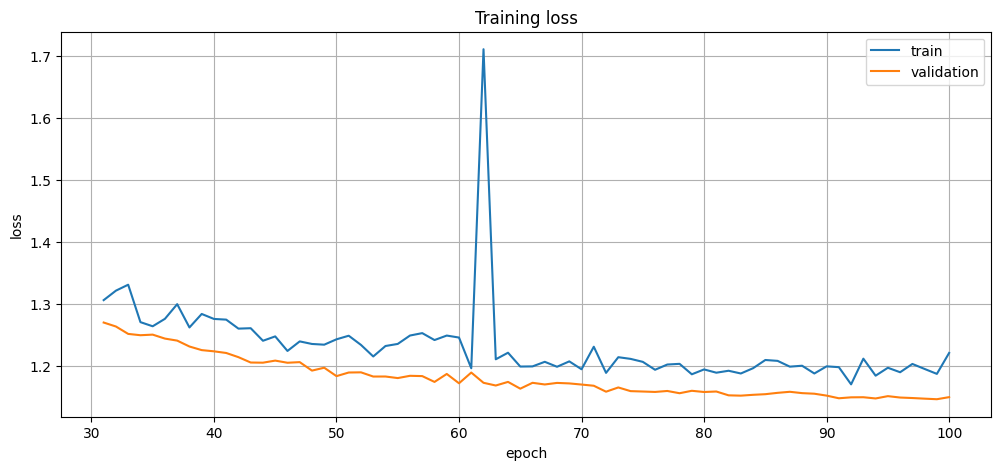

In [19]:
epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row["val_loss"] for row in history]


plt.figure(figsize=(12, 5))

plt.plot(
    epochs,
    train_losses,
    label="train",
)

plt.plot(
    epochs,
    val_losses,
    label="validation",
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True)
plt.legend()
plt.show()

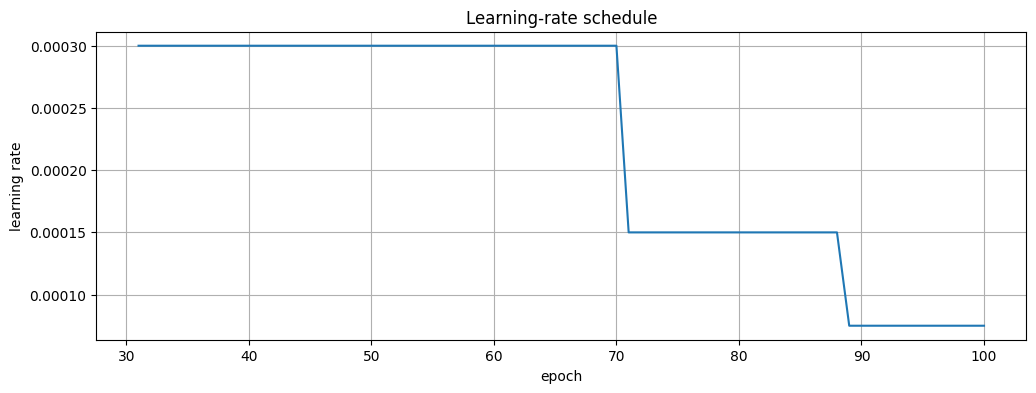

In [20]:
learning_rates = [
    row["learning_rate"]
    for row in history
]

plt.figure(figsize=(12, 4))

plt.plot(
    epochs,
    learning_rates,
)

plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.title("Learning-rate schedule")
plt.grid(True)
plt.show()

# 17. Evaluate the best checkpoint on the test sequences

In [21]:
best_checkpoint = load_training_checkpoint(
    BEST_CHECKPOINT_PATH,
    model=model,
    map_location=DEVICE,
    restore_rng_state=False,
)


test_augmentation_generator = make_augmentation_generator(
    TEST_AUGMENTATION_SEED
)


test_metrics, _ = run_epoch(
    test_loader,
    training=False,
    augmentation_generator=test_augmentation_generator,
)


print("Test metrics:")

for key, value in sorted(test_metrics.items()):
    print(f"{key}: {value}")

/home/camel/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Test metrics:
epoch_time_s: 79.9366206160048
imu/change_time_error_s: 0.5070389940383586
imu/event_accuracy: 0.45673758865248226
imu/loss_change_event: 0.6946167245824286
imu/loss_change_time: 0.008241162854676128
imu/loss_rotation: 0.33059328693024653
imu/loss_time_offset: 0.09207625260959704
imu/loss_translation: 0.3903741591365625
imu/rotation_error_deg: 6.4592488593243536
imu/time_offset_error_ms: 3.3428808787190323
imu/translation_error_cm: 7.035407355829333
lidar/change_time_error_s: 0.45225762475466896
lidar/event_accuracy: 0.5347517730496454
lidar/loss_change_event: 0.6924720518132473
lidar/loss_change_time: 0.007194609201516534
lidar/loss_rotation: 0.3083187517069333
lidar/loss_time_offset: 0.07172298938818672
lidar/loss_translation: 0.38130194392610106
lidar/rotation_error_deg: 6.1202228705088295
lidar/time_offset_error_ms: 3.1516721823536757
lidar/translation_error_cm: 6.934896435974338
loss_total: 1.1767759363702004
samples_per_s: 8.819487170800485


# Evaluation

In [22]:
from obscalib.data.collation import collate_windows
from obscalib.geometry.lie import se3_log

In [23]:
##################################################
# Prediction visualization configuration
##################################################

VIS_SEQUENCE_NAME = "Urban38"

# Offset within this sequence's WindowSample list.
VIS_START_WINDOW = 0

# Number of consecutive windows to evaluate and plot.
VIS_NUM_WINDOWS = 80

# Evaluation batch size. This can be smaller than the training batch size.
VIS_BATCH_SIZE = 16

# Use a separate deterministic augmentation realization for visualization.
VIS_AUGMENTATION_SEED = 56789

In [24]:
sequence_indices = [
    index
    for index in range(len(test_dataset))
    if test_dataset.sequence_name_for_window(index) == VIS_SEQUENCE_NAME
]

if not sequence_indices:
    raise ValueError(f"Sequence {VIS_SEQUENCE_NAME!r} is not present in test_dataset.")

selected_indices = sequence_indices[
    VIS_START_WINDOW : VIS_START_WINDOW + VIS_NUM_WINDOWS
]

if not selected_indices:
    raise ValueError("Selected visualization window range is empty.")

print("Sequence:", VIS_SEQUENCE_NAME)
print("Selected windows:", len(selected_indices))
print("Dataset indices:", selected_indices[0], "...", selected_indices[-1])

Sequence: Urban38
Selected windows: 80
Dataset indices: 0 ... 79


# run augmentation + model and collect predictions

In [25]:
def collect_calibration_predictions(dataset, indices, *, batch_size, augmentation_seed):
    """Run selected dataset windows and collect initial, reference, and predicted calibration corrections."""

    model.eval()

    augmentation_generator = make_augmentation_generator(
        augmentation_seed
    )

    collected = {
        calibration_key: {
            "reference_delta_xi": [],
            "predicted_delta_xi": [],
            "reference_delta_tau": [],
            "predicted_delta_tau": [],
            "event_label": [],
            "event_probability": [],
            "reference_change_time": [],
            "predicted_change_time": [],
        }
        for calibration_key in model_config.head_keys
    }

    with torch.no_grad():
        for start in range(0, len(indices), batch_size):
            batch_indices = indices[start : start + batch_size]

            base_window = collate_windows(
                [dataset[index] for index in batch_indices]
            )

            base_window = window_batch_to(
                base_window,
                DEVICE,
                dtype=MODEL_DTYPE,
            )

            augmentation_result = augmentation_pipeline(
                base_window,
                generator=augmentation_generator,
            )

            augmented_window = augmentation_result.augmented_window

            step_result = window_step(
                augmented_window
            )

            for calibration_key, prediction in step_result.model_output.predictions.items():
                target = augmented_window.targets[calibration_key]
                current_state = augmented_window.current_calibration[calibration_key]

                ##################################################
                # Reference correction used by the training loss
                ##################################################

                reference_delta_transform = (
                    target.next_transform
                    @ torch.linalg.inv(current_state.transform)
                )

                reference_delta_xi = se3_log(
                    reference_delta_transform
                )

                reference_delta_tau = (
                    target.next_time_offset
                    - current_state.time_offset
                )

                ##################################################
                # Collect reference and model prediction
                ##################################################

                collected[calibration_key]["reference_delta_xi"].append(
                    reference_delta_xi.cpu()
                )

                collected[calibration_key]["predicted_delta_xi"].append(
                    prediction.delta_xi.cpu()
                )

                collected[calibration_key]["reference_delta_tau"].append(
                    reference_delta_tau.cpu()
                )

                collected[calibration_key]["predicted_delta_tau"].append(
                    prediction.delta_tau.cpu()
                )

                collected[calibration_key]["event_label"].append(
                    target.change_label.cpu()
                )

                collected[calibration_key]["event_probability"].append(
                    torch.sigmoid(prediction.change_event_logit).cpu()
                )

                collected[calibration_key]["reference_change_time"].append(
                    target.change_time.cpu()
                )

                collected[calibration_key]["predicted_change_time"].append(
                    prediction.change_time.cpu()
                )

    ##################################################
    # Concatenate batches
    ##################################################

    for calibration_key in collected:
        for field_name in collected[calibration_key]:
            collected[calibration_key][field_name] = torch.cat(
                collected[calibration_key][field_name],
                dim=0,
            ).numpy()

    return collected


visualization_results = collect_calibration_predictions(
    test_dataset,
    selected_indices,
    batch_size=VIS_BATCH_SIZE,
    augmentation_seed=VIS_AUGMENTATION_SEED,
)

# plot reference vs prediction vs initial correction

In [26]:
CALIBRATION_COMPONENT_NAMES = (
    "phi_x",
    "phi_y",
    "phi_z",
    "rho_x",
    "rho_y",
    "rho_z",
)


def plot_calibration_corrections(results, calibration_key, window_stride_s):
    """Plot reference and predicted correction relative to the initial supplied calibration."""

    result = results[calibration_key]

    reference_xi = result["reference_delta_xi"]
    predicted_xi = result["predicted_delta_xi"]

    reference_tau = result["reference_delta_tau"][:, 0]
    predicted_tau = result["predicted_delta_tau"][:, 0]

    times_s = np.arange(len(reference_xi)) * window_stride_s

    fig, axes = plt.subplots(
        7,
        1,
        figsize=(15, 16),
        sharex=True,
    )

    ##################################################
    # Rotation correction
    ##################################################

    for component_index in range(3):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(reference_xi[:, component_index]),
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            np.rad2deg(predicted_xi[:, component_index]),
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [deg]"
        )

        axes[component_index].grid(True)
        axes[component_index].legend()

    ##################################################
    # Translational SE3 tangent correction
    ##################################################

    for component_index in range(3, 6):
        axes[component_index].plot(
            times_s,
            np.zeros_like(times_s),
            label="initial",
        )

        axes[component_index].plot(
            times_s,
            100.0 * reference_xi[:, component_index],
            label="reference",
        )

        axes[component_index].plot(
            times_s,
            100.0 * predicted_xi[:, component_index],
            label="predicted",
        )

        axes[component_index].set_ylabel(
            f"{CALIBRATION_COMPONENT_NAMES[component_index]} [cm]"
        )

        axes[component_index].grid(True)
        axes[component_index].legend()

    ##################################################
    # Temporal correction
    ##################################################

    axes[6].plot(
        times_s,
        np.zeros_like(times_s),
        label="initial",
    )

    axes[6].plot(
        times_s,
        1000.0 * reference_tau,
        label="reference",
    )

    axes[6].plot(
        times_s,
        1000.0 * predicted_tau,
        label="predicted",
    )

    axes[6].set_ylabel("delta_tau [ms]")
    axes[6].set_xlabel("time across selected windows [s]")

    axes[6].grid(True)
    axes[6].legend()

    fig.suptitle(
        f"{calibration_key}: calibration correction prediction"
    )

    fig.tight_layout()
    plt.show()

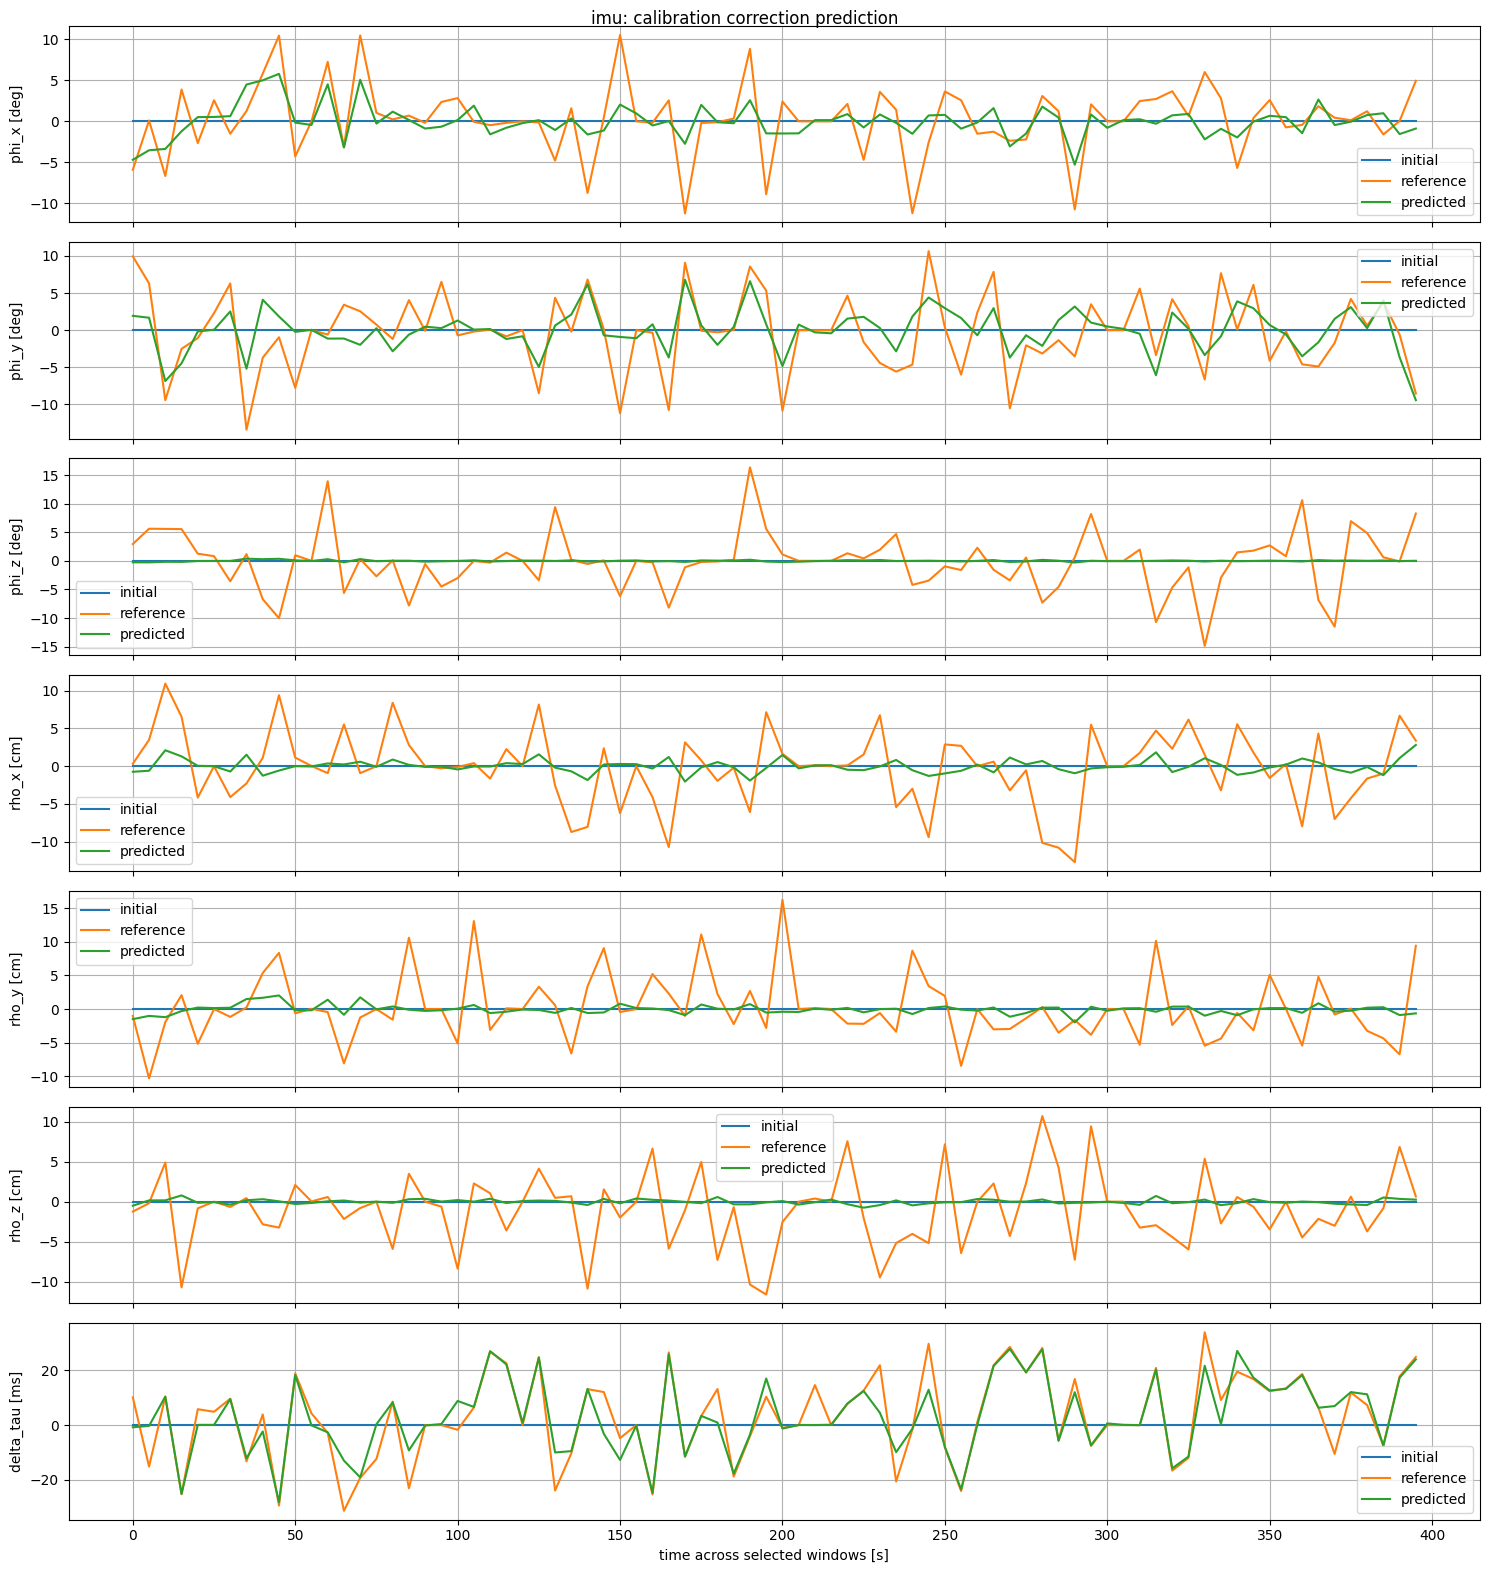

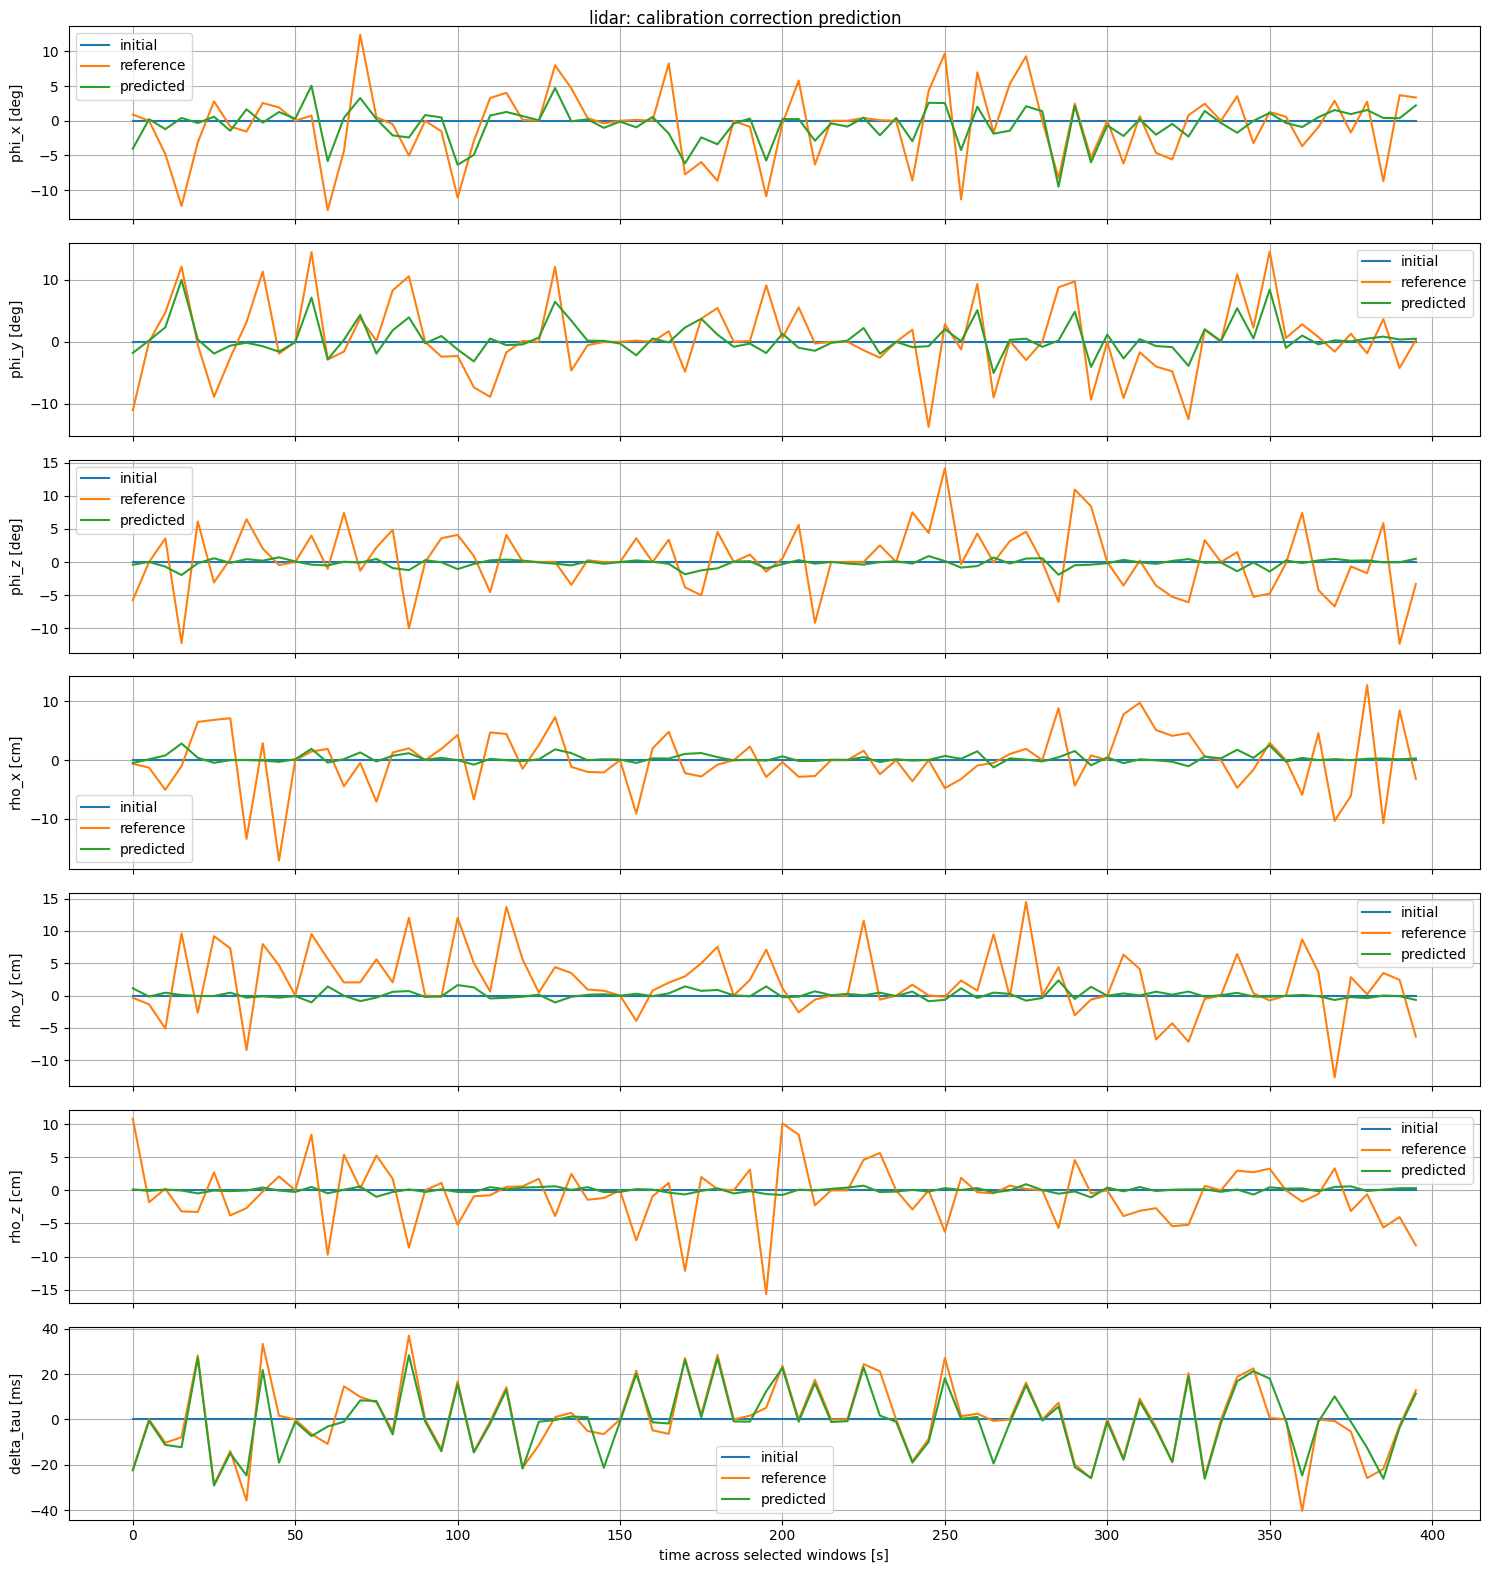

In [27]:
plot_calibration_corrections(
    visualization_results,
    "imu",
    WINDOW_STRIDE_S,
)

plot_calibration_corrections(
    visualization_results,
    "lidar",
    WINDOW_STRIDE_S,
)

# plot total correction magnitude

In [28]:
def plot_correction_magnitudes(results, calibration_key, window_stride_s):
    """Plot scalar spatial and temporal correction magnitudes."""

    result = results[calibration_key]

    reference_xi = result["reference_delta_xi"]
    predicted_xi = result["predicted_delta_xi"]

    reference_tau = result["reference_delta_tau"][:, 0]
    predicted_tau = result["predicted_delta_tau"][:, 0]

    times_s = np.arange(len(reference_xi)) * window_stride_s

    reference_rotation_deg = np.rad2deg(
        np.linalg.norm(reference_xi[:, :3], axis=1)
    )

    predicted_rotation_deg = np.rad2deg(
        np.linalg.norm(predicted_xi[:, :3], axis=1)
    )

    reference_translation_cm = 100.0 * np.linalg.norm(
        reference_xi[:, 3:],
        axis=1,
    )

    predicted_translation_cm = 100.0 * np.linalg.norm(
        predicted_xi[:, 3:],
        axis=1,
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 9),
        sharex=True,
    )

    axes[0].plot(
        times_s,
        reference_rotation_deg,
        label="reference",
    )

    axes[0].plot(
        times_s,
        predicted_rotation_deg,
        label="predicted",
    )

    axes[0].axhline(
        0.0,
        label="initial",
    )

    axes[0].set_ylabel("rotation [deg]")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(
        times_s,
        reference_translation_cm,
        label="reference",
    )

    axes[1].plot(
        times_s,
        predicted_translation_cm,
        label="predicted",
    )

    axes[1].axhline(
        0.0,
        label="initial",
    )

    axes[1].set_ylabel("rho norm [cm]")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(
        times_s,
        1000.0 * reference_tau,
        label="reference",
    )

    axes[2].plot(
        times_s,
        1000.0 * predicted_tau,
        label="predicted",
    )

    axes[2].axhline(
        0.0,
        label="initial",
    )

    axes[2].set_ylabel("delta_tau [ms]")
    axes[2].set_xlabel("time across selected windows [s]")
    axes[2].grid(True)
    axes[2].legend()

    fig.suptitle(
        f"{calibration_key}: correction magnitudes"
    )

    fig.tight_layout()
    plt.show()

In [29]:
def plot_event_predictions(results, calibration_key, window_stride_s):
    """Plot true calibration events, predicted probabilities, and event times."""

    result = results[calibration_key]

    event_label = result["event_label"][:, 0]
    event_probability = result["event_probability"][:, 0]

    reference_change_time = result["reference_change_time"][:, 0]
    predicted_change_time = result["predicted_change_time"][:, 0]

    times_s = np.arange(len(event_label)) * window_stride_s

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 7),
        sharex=True,
    )

    ##################################################
    # Event classification
    ##################################################

    axes[0].step(
        times_s,
        event_label,
        where="mid",
        label="true event",
    )

    axes[0].plot(
        times_s,
        event_probability,
        label="predicted probability",
    )

    axes[0].axhline(
        0.5,
        linestyle="--",
        label="classification threshold",
    )

    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_ylabel("event")
    axes[0].grid(True)
    axes[0].legend()

    ##################################################
    # Change-time prediction for actual events only
    ##################################################

    event_mask = event_label > 0.5

    axes[1].plot(
        times_s[event_mask],
        reference_change_time[event_mask],
        marker="o",
        label="reference change time",
    )

    axes[1].plot(
        times_s[event_mask],
        predicted_change_time[event_mask],
        marker="o",
        label="predicted change time",
    )

    axes[1].set_ylabel("time within window [s]")
    axes[1].set_xlabel("time across selected windows [s]")
    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(
        f"{calibration_key}: calibration-event prediction"
    )

    fig.tight_layout()
    plt.show()

In [30]:
def print_initial_vs_model_errors(results, calibration_key):
    """Compare the trained model against a zero-correction baseline."""

    result = results[calibration_key]

    reference_xi = result["reference_delta_xi"]
    predicted_xi = result["predicted_delta_xi"]

    reference_tau = result["reference_delta_tau"][:, 0]
    predicted_tau = result["predicted_delta_tau"][:, 0]

    ##################################################
    # Initial calibration means predicted correction = 0
    ##################################################

    initial_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            reference_xi[:, :3],
            axis=1,
        )
    )

    model_rotation_error_deg = np.rad2deg(
        np.linalg.norm(
            predicted_xi[:, :3] - reference_xi[:, :3],
            axis=1,
        )
    )

    initial_translation_error_cm = 100.0 * np.linalg.norm(
        reference_xi[:, 3:],
        axis=1,
    )

    model_translation_error_cm = 100.0 * np.linalg.norm(
        predicted_xi[:, 3:] - reference_xi[:, 3:],
        axis=1,
    )

    initial_tau_error_ms = 1000.0 * np.abs(
        reference_tau
    )

    model_tau_error_ms = 1000.0 * np.abs(
        predicted_tau - reference_tau
    )

    print(calibration_key)
    print()
    print(
        f"rotation:    initial={initial_rotation_error_deg.mean():.3f} deg, "
        f"model={model_rotation_error_deg.mean():.3f} deg"
    )
    print(
        f"translation: initial={initial_translation_error_cm.mean():.3f} cm, "
        f"model={model_translation_error_cm.mean():.3f} cm"
    )
    print(
        f"time offset: initial={initial_tau_error_ms.mean():.3f} ms, "
        f"model={model_tau_error_ms.mean():.3f} ms"
    )

In [31]:
print_initial_vs_model_errors(
    visualization_results,
    "imu",
)

print()

print_initial_vs_model_errors(
    visualization_results,
    "lidar",
)

imu

rotation:    initial=6.749 deg, model=6.054 deg
translation: initial=6.791 cm, model=6.757 cm
time offset: initial=13.014 ms, model=3.674 ms

lidar

rotation:    initial=7.285 deg, model=6.191 deg
translation: initial=7.044 cm, model=7.114 cm
time offset: initial=11.722 ms, model=3.751 ms


In [32]:
def print_prediction_collapse_diagnostics(results, calibration_key):
    result = results[calibration_key]

    reference_xi = result["reference_delta_xi"]
    predicted_xi = result["predicted_delta_xi"]

    names = (
        "phi_x",
        "phi_y",
        "phi_z",
        "rho_x",
        "rho_y",
        "rho_z",
    )

    print(calibration_key)
    print()

    for index, name in enumerate(names):
        target = reference_xi[:, index]
        prediction = predicted_xi[:, index]

        if np.std(target) > 0.0 and np.std(prediction) > 0.0:
            correlation = np.corrcoef(target, prediction)[0, 1]
        else:
            correlation = np.nan

        print(
            f"{name:5s}  "
            f"target std={np.std(target):.5f}  "
            f"pred std={np.std(prediction):.5f}  "
            f"corr={correlation:+.3f}"
        )


print_prediction_collapse_diagnostics(
    visualization_results,
    "imu",
)

print()

print_prediction_collapse_diagnostics(
    visualization_results,
    "lidar",
)

imu

phi_x  target std=0.07437  pred std=0.03426  corr=+0.656
phi_y  target std=0.08999  pred std=0.05028  corr=+0.658
phi_z  target std=0.09013  pred std=0.00228  corr=-0.039
rho_x  target std=0.04828  pred std=0.00869  corr=+0.247
rho_y  target std=0.04868  pred std=0.00678  corr=+0.217
rho_z  target std=0.04471  pred std=0.00288  corr=+0.127

lidar

phi_x  target std=0.08836  pred std=0.04346  corr=+0.671
phi_y  target std=0.10173  pred std=0.04507  corr=+0.712
phi_z  target std=0.08280  pred std=0.01034  corr=+0.211
rho_x  target std=0.05047  pred std=0.00712  corr=+0.024
rho_y  target std=0.04977  pred std=0.00630  corr=+0.156
rho_z  target std=0.04425  pred std=0.00376  corr=+0.077
